# 📐 プロジェクトに必要な数学基礎
**線形代数・統計・微積分を実装レベルで理解する**

---

## 📚 目次
1. [線形代数: ベクトルと行列](#1-線形代数)
2. [コサイン類似度 (RAG 検索の核心)](#2-コサイン類似度)
3. [確率・統計の基礎](#3-確率統計の基礎)
4. [微積分: 勾配降下法](#4-勾配降下法)
5. [Softmax と情報理論](#5-softmax-と情報理論)
6. [プロジェクトへの応用まとめ](#6-プロジェクトへの応用)

## 1. 線形代数

### ベクトル演算 - テキスト埋め込みの基礎

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント自動設定

# ── ベクトルの基本演算 ──
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 0.5, -1.0])

print("ベクトル a :", a)
print("ベクトル b :", b)
print()
print("a + b       :", a + b)
print("a - b       :", a - b)
print("2 * a       :", 2 * a)
print("内積 a·b    :", np.dot(a, b))
print("‖a‖ (L2ノルム):", np.linalg.norm(a).round(4))
print("‖b‖          :", np.linalg.norm(b).round(4))

# L2 ノルム = 埋め込みベクトルの大きさ（余弦類似度の分母に使う）

ベクトル a : [1. 2. 3.]
ベクトル b : [ 4.   0.5 -1. ]

a + b       : [5.  2.5 2. ]
a - b       : [-3.   1.5  4. ]
2 * a       : [2. 4. 6.]
内積 a·b    : 2.0
‖a‖ (L2ノルム): 3.7417
‖b‖          : 4.1533


In [7]:
# ── 行列演算 ──
# LLM の重み行列の縮小版イメージ
W = np.array([[1, 0, -1],   # 重み行列 (output=2, input=3)
              [0, 1,  2]], dtype=float)
x = np.array([1, 2, 3], dtype=float)  # 入力ベクトル

y = W @ x  # 行列とベクトルの積 → 線形変換
print("重み行列 W:")
print(W)
print("\n入力 x:", x)
print("出力 y = W @ x:", y)
print()
print("→ この変換が全結合層 (Linear Layer) の本質")

重み行列 W:
[[ 1.  0. -1.]
 [ 0.  1.  2.]]

入力 x: [1. 2. 3.]
出力 y = W @ x: [-2.  8.]

→ この変換が全結合層 (Linear Layer) の本質


## 2. コサイン類似度

RAG 検索で「クエリと文書がどれだけ似ているか」を測る

In [8]:
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cos

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

# 擬似的な埋め込みで確認
np.random.seed(0)
# クエリ: "機械学習について教えて"
query = np.random.randn(16)

# 3 つの文書埋め込み（擬似）
doc_ml   = query + np.random.randn(16) * 0.1    # 高類似（同トピック）
doc_food = np.random.randn(16)                   # 低類似（別トピック）
doc_ai   = query + np.random.randn(16) * 0.5    # 中類似

docs = {
    "文書A (機械学習)": doc_ml,
    "文書B (料理)    ": doc_food,
    "文書C (AI一般) ": doc_ai,
}

print("クエリとの類似度:")
for name, doc in docs.items():
    sim = cosine_sim(query, doc)
    bar = "▓" * int((sim+1)*10)
    print(f"  {name}: {sim:.4f}  {bar}")

クエリとの類似度:
  文書A (機械学習): 0.9934  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  文書B (料理)    : -0.0089  ▓▓▓▓▓▓▓▓▓
  文書C (AI一般) : 0.9251  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


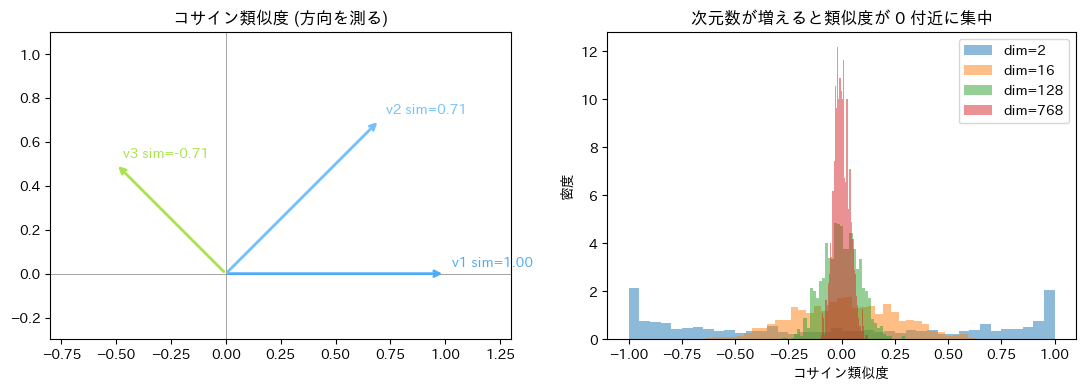

In [9]:
# コサイン類似度 vs ユークリッド距離 の違いを可視化
theta = np.linspace(0, 2*np.pi, 100)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左: 2D ベクトルのコサイン
v1 = np.array([1, 0])
v2 = np.array([0.7, 0.7])
v3 = np.array([-0.5, 0.5])

ax = axes[0]
for v, lbl, c in [(v1,"v1","#4dabf7"),(v2,"v2","#74c0fc"),(v3,"v3","#a9e34b")]:
    ax.annotate("", xy=v, xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(v[0]+0.03, v[1]+0.03, f"{lbl} sim={cosine_sim(v1,v):.2f}", color=c)
ax.set_xlim(-0.8, 1.3); ax.set_ylim(-0.3, 1.1)
ax.set_title("コサイン類似度 (方向を測る)")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")

# 右: 高次元の分布（ランダムベクトルの類似度分布）
n_dims = [2, 16, 128, 768]
ax = axes[1]
for d in n_dims:
    sims = []
    for _ in range(1000):
        a, b = np.random.randn(d), np.random.randn(d)
        sims.append(cosine_sim(a, b))
    ax.hist(sims, bins=40, alpha=0.5, label=f"dim={d}", density=True)
ax.set_xlabel("コサイン類似度"); ax.set_ylabel("密度")
ax.set_title("次元数が増えると類似度が 0 付近に集中")
ax.legend()

plt.tight_layout(); plt.show()

## 3. 確率・統計の基礎

ロジット : [2.0, 1.0, 0.5, -1.0]
確率     : ['0.6095', '0.2242', '0.1360', '0.0303']
合計     : 1.0


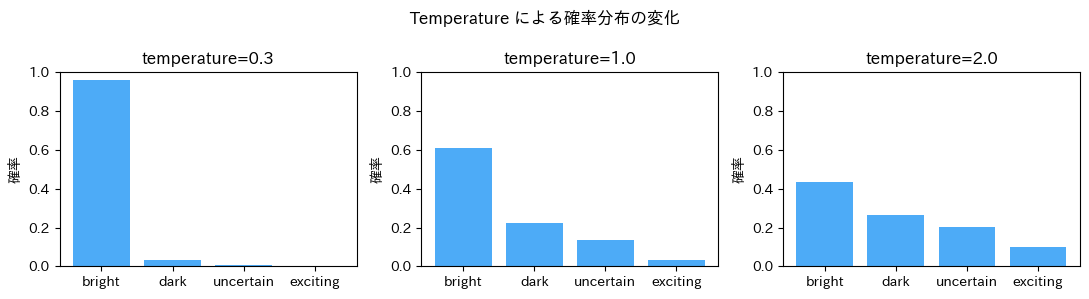

In [10]:
import torch
import torch.nn.functional as F

# ── Softmax ── 確率分布への変換
logits = torch.tensor([2.0, 1.0, 0.5, -1.0])
probs  = F.softmax(logits, dim=0)

print("ロジット :", logits.tolist())
print("確率     :", [f"{p:.4f}" for p in probs.tolist()])
print("合計     :", probs.sum().item())

# Temperature の効果
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
temps = [0.3, 1.0, 2.0]
words = ["bright", "dark", "uncertain", "exciting"]
for ax, T in zip(axes, temps):
    p = F.softmax(logits / T, dim=0)
    ax.bar(words, p.numpy(), color="#4dabf7")
    ax.set_ylim(0, 1); ax.set_title(f"temperature={T}")
    ax.set_ylabel("確率")
plt.suptitle("Temperature による確率分布の変化")
plt.tight_layout(); plt.show()

In [11]:
# ── 平均・分散・標準化 (Layer Normalization の基礎) ──
x = torch.tensor([2.0, 4.0, 1.0, 7.0, 3.0])

mean = x.mean()
var  = x.var(unbiased=False)
std  = x.std(unbiased=False)
x_norm = (x - mean) / (std + 1e-5)

print(f"元データ : {x.numpy()}")
print(f"平均     : {mean.item():.4f}")
print(f"分散     : {var.item():.4f}")
print(f"標準偏差 : {std.item():.4f}")
print(f"正規化後 : {x_norm.numpy().round(4)}")
print()
print("→ LayerNorm はこれをトークンの hidden dim 方向に適用する")

元データ : [2. 4. 1. 7. 3.]
平均     : 3.4000
分散     : 4.2400
標準偏差 : 2.0591
正規化後 : [-0.6799  0.2914 -1.1655  1.7483 -0.1943]

→ LayerNorm はこれをトークンの hidden dim 方向に適用する


## 4. 勾配降下法

損失を最小化するためにパラメータを更新する

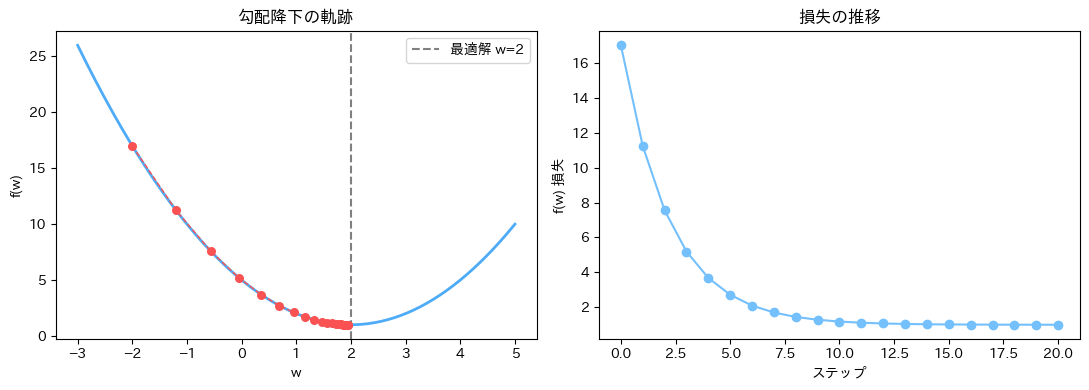

最終 w=1.9539  f=1.0021  (正解: w=2, f=1)


In [12]:
# ── 1次元の関数を勾配降下で最小化 ──
import numpy as np
import matplotlib.pyplot as plt

def f(w):    return (w - 2)**2 + 1      # 最小値: w=2, f=1
def df_dw(w): return 2 * (w - 2)        # 勾配（微分）

w      = -2.0   # 初期値
lr     = 0.1    # 学習率
steps  = 20

ws, fs = [w], [f(w)]
for _ in range(steps):
    grad = df_dw(w)
    w   -= lr * grad
    ws.append(w); fs.append(f(w))

x_plot = np.linspace(-3, 5, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(x_plot, [f(x) for x in x_plot], color="#4dabf7", lw=2)
ax1.scatter(ws, fs, color="#fa5252", zorder=5, s=30)
ax1.plot(ws, fs, color="#fa5252", lw=1, ls="--")
ax1.set_xlabel("w"); ax1.set_ylabel("f(w)")
ax1.set_title("勾配降下の軌跡")
ax1.axvline(2, color="gray", ls="--", label="最適解 w=2")
ax1.legend()

ax2.plot(fs, "o-", color="#74c0fc")
ax2.set_xlabel("ステップ"); ax2.set_ylabel("f(w) 損失")
ax2.set_title("損失の推移")

plt.tight_layout(); plt.show()
print(f"最終 w={ws[-1]:.4f}  f={fs[-1]:.4f}  (正解: w=2, f=1)")

## 5. Softmax と情報理論

In [13]:
import numpy as np

# ── クロスエントロピー損失 ──
def cross_entropy(y_true, y_pred_logits):
    probs = np.exp(y_pred_logits) / np.exp(y_pred_logits).sum()
    return -np.log(probs[y_true] + 1e-9)

# 例: 3クラス分類
y_true = 1  # 正解クラスは 1

cases = [
    ("完璧な予測",      [0.0, 10.0, 0.0]),
    ("正解クラス高め",  [0.0,  2.0, 0.0]),
    ("均一（不確か）",  [0.0,  0.0, 0.0]),
    ("間違い予測",      [5.0, -1.0, 0.0]),
]

print(f"{'ケース':<20} {'損失':>8}")
print("─" * 35)
for name, logits in cases:
    loss = cross_entropy(y_true, logits)
    bar  = "▓" * min(int(loss * 3), 20)
    print(f"{name:<20} {loss:8.4f}  {bar}")

print()
print("→ 正しい予測に自信があるほど損失が低い")
print("→ 間違った予測に自信があるほど損失が高い")

ケース                        損失
───────────────────────────────────
完璧な予測                  0.0001  
正解クラス高め                0.2395  
均一（不確か）                1.0986  ▓▓▓
間違い予測                  6.0092  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

→ 正しい予測に自信があるほど損失が低い
→ 間違った予測に自信があるほど損失が高い


## 6. プロジェクトへの応用

各数学概念がプロジェクトのどこに使われているかまとめ

In [14]:
# プロジェクト内での数学の役割マップ
math_map = {
    "線形代数 (行列積)":       ["Transformer の全結合層", "埋め込み変換"],
    "コサイン類似度":          ["FAISS ベクトル検索", "RAG 文書ランキング"],
    "Softmax + 確率分布":     ["次のトークン選択", "temperature 制御"],
    "勾配降下法":              ["ファインチューニング", "モデル訓練"],
    "クロスエントロピー損失":  ["分類タスクの最適化", "LM の訓練損失"],
    "Layer Normalization":    ["Transformer 各ブロック", "訓練の安定化"],
}

print(f"{'数学概念':<25} {'プロジェクト内での使用場所'}")
print("─" * 70)
for concept, usages in math_map.items():
    print(f"{concept:<25} {', '.join(usages)}")

数学概念                      プロジェクト内での使用場所
──────────────────────────────────────────────────────────────────────
線形代数 (行列積)                Transformer の全結合層, 埋め込み変換
コサイン類似度                   FAISS ベクトル検索, RAG 文書ランキング
Softmax + 確率分布            次のトークン選択, temperature 制御
勾配降下法                     ファインチューニング, モデル訓練
クロスエントロピー損失               分類タスクの最適化, LM の訓練損失
Layer Normalization       Transformer 各ブロック, 訓練の安定化


## ✅ 理解度チェック

- [ ] ベクトルの内積とコサイン類似度の関係が説明できる  
- [ ] temperature が高いほど確率分布が平坦になる理由が分かった  
- [ ] 勾配降下法の「学習率が大きすぎると発散する」理由が理解できた  
- [ ] クロスエントロピーが「正解クラスの確率を上げる」損失だと分かった  

---
✅ **全学習資料を修了しました！** 次は実際のコードを動かしてみよう 🎉